<a href="https://colab.research.google.com/github/UN-Task-Team-for-Scanner-Data/alternative-data-sources-price-statistics/blob/main/6_index_methods/Index_Calculation_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>Index Calculation in R</b></h1>

# Preparation

## Setup

This notebook shows how to calculate price indices in an R environment. In order to do this we have to install and load some packages. First and foremost, we will use the package `PriceIndices` to calculate price indices. An alternative package `IndexNumR` is also presented. Other than that we use popular packages for data manipulation and visualisation.

In [1]:
install.packages('pacman') # package management tool
pacman::p_load(PriceIndices, IndexNumR, ggplot2, tidyverse, lubridate) # installation and loading of the packages
options(tidyverse.quiet = TRUE) # removes warnings

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Dataset

We use data from a set of food prices in Italian supermarkets provided by Banca d'Italia, Università Campus Bio-Medico and Università degli Studi della Tuscia. The complete dataset is available [here](https://zenodo.org/records/14927602). We aggregated the data by month and added artificial quantities.

> **Note:** Each row represents one product in one month, showing price and quantity sold.


In [2]:
url_avg_price_data <- paste0(
  'https://raw.githubusercontent.com/UN-Task-Team-for-Scanner-Data/',
  'alternative-data-sources-price-statistics/refs/heads/main/data/',
  'monthly_avg_price_with_qty.csv'
)

data_raw <- read_csv(url_avg_price_data, show_col_types = FALSE)
head(data_raw)

month_year,product,store_id,COICOP5,COICOP4,price,quantity,total_quantity,quantity_share
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,443.9526,998075.4,0.0004448087
2021-01,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,462.0903,1075015.9,0.0004298450
2021-02,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,451.6173,1088432.1,0.0004149246
2021-03,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,439.1331,1124145.1,0.0003906374
2021-04,abate arg biologico 600.0 gr,6,Pears,Fruit,3.78,378.1872,1084118.1,0.0003488432
2021-05,abate arg biologico 600.0 gr,6,Pears,Fruit,3.78,394.0985,1080937.4,0.0003645895


## Data preparation

Before calculating indices we need to prepare the data carefully. Two main steps:

1. **Filter to a homogeneous set of products and stores.** Different regions or store types should not be mixed when calculating elementary indices, as price levels can differ systematically between them. We restrict the data to apples sold in store 3.

2. **Harmonise prices to a common unit.** Products come in different package sizes (e.g. 1 kg bag vs. 500 g bag). To make prices comparable we convert all prices to price per kilogram and adjust quantities accordingly to keep expenditure consistent.

> **Important:** This adjustment affects the Dutot index, which uses arithmetic means of prices and is therefore sensitive to the unit of measurement.


In [3]:
# Filter for apples in Store 3
data <- data_raw %>%
  filter(COICOP5 %in% "Apples" & store_id %in% 2) %>%
  mutate(
    product_id = as.numeric(factor(product)),
    volume = price * quantity,
    total_quantity = NULL, quantity_share = NULL
  )

# Extract package size from product description and convert to kg
data <- data %>%
  mutate(
    size = case_when(
      str_sub(product, -2, -1) == "kg" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")),
      str_sub(product, -2, -1) == "gr" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) / 1000,
      str_sub(product, -2, -1) == "pz" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) * .18)
  )

# Adjust price to per kg and quantity to kg sold
data <- data %>%
   mutate(
     price = price / size,
     quantity = quantity * size
   )

head(data)

month_year,product,store_id,COICOP5,COICOP4,price,quantity,product_id,volume,size
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,annurca igp 1.0 kg,2,Apples,Fruit,2.49,156.9064,1,390.6970,1
2021-01,annurca igp 1.0 kg,2,Apples,Fruit,2.49,150.8459,1,375.6063,1
2021-02,annurca igp 1.0 kg,2,Apples,Fruit,2.49,149.6250,1,372.5662,1
2021-03,annurca igp 1.0 kg,2,Apples,Fruit,2.49,152.3413,1,379.3298,1
2021-04,annurca igp 1.0 kg,2,Apples,Fruit,2.49,157.4845,1,392.1364,1
2021-05,annurca igp 1.0 kg,2,Apples,Fruit,2.49,128.6316,1,320.2927,1


# Price Index Packages

## The `PriceIndices` package

`PriceIndices` is an R package for price index calculation written by Jacek Bialek. A [user guide](https://github.com/JacekBialek/important_documents/blob/main/README.pdf) and a more detailed [manual](https://github.com/JacekBialek/important_documents/blob/main/PriceIndices_manual.pdf) are available.    
The core of the package consists of functions to calculate both bilateral and multilateral indices. It has an extensive variety of price index formulas and methods. Furthermore it includes a data set from Polish supermarkets. There are some functions for data processing (e.g. price imputation for missing prices, data aggregation, filtering, stratification) as well as some functions to compare results and visualise data.

The package only calculates monthly indices, and the datasets must meet some conditions. It must contain the following correctly named columns:

| Column | Type | Description |
|---|---|---|
| `time` | Date `yyyy-mm-dd` | Observation period |
| `prodID` | numeric / character | Product identifier |
| `prices` | numeric > 0 | Price |
| `quantities` | numeric > 0 | Quantity sold |    

<br>

The formatting can be done using typical data processing functions or by using the function `PriceIndices::data_preparing`.

How to apply the functions in this package to specific indices is explained throughout the notebook.

In [4]:
# We start by correctly naming the columns and changing the format of time to date
cat("This dataframe has the columns that PriciIndices needs:\n")
data_preparing(
  data,
  time = "month_year", # convert the period into date format and rename the column and
  prices = "price",
  quantities = "quantity",
  retID = "store_id",
  description = "product",
  grammage = "size",
  prodID = "product_id",
  zero_prices = F,
  zero_quantities = F
) %>%
  head()

# Let's add the required columns to the initial data.frame
data <- data %>%
  mutate(
    prices     = price,
    quantities = quantity,
    prodID     = product_id,
    time       = as.Date(paste(month_year, "01", sep = "-"))
  )


# The price_indices function calculates multiple indices in a single step and returns a data.frame
indices <- price_indices(data,
  start = "2020-12",
  end = "2022-12",
  formula = c("jevons", "chjevons", "laspeyres", "chlaspeyres", "tornqvist", "chtornqvist"),
  interval = TRUE
)

cat("\n\nThe function returns a data frame that looks like this:")
head(indices)
cat("\n\nMethods starting with 'ch' are monthly chained indices,
while the others are fixed-base indices.")

This dataframe has the columns that PriciIndices needs:


time,prices,quantities,prodID,retID,description,grammage
<date>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
2020-12-01,2.49,156.9064,1,2,annurca igp 1.0 kg,1
2021-01-01,2.49,150.8459,1,2,annurca igp 1.0 kg,1
2021-02-01,2.49,149.6250,1,2,annurca igp 1.0 kg,1
2021-03-01,2.49,152.3413,1,2,annurca igp 1.0 kg,1
2021-04-01,2.49,157.4845,1,2,annurca igp 1.0 kg,1
2021-05-01,2.49,128.6316,1,2,annurca igp 1.0 kg,1




The function returns a data frame that looks like this:

,time,jevons,chjevons,laspeyres,chlaspeyres,tornqvist,chtornqvist
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2020-12,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000
2,2021-01,0.9925384,0.9925384,0.9735729,0.9735729,0.9727744,0.9727744
3,2021-02,0.9959999,0.9956883,0.9838349,0.9875629,0.9825679,0.9846873
4,2021-03,1.0150183,1.0221489,1.0076353,1.0380432,1.0074052,1.0346296
5,2021-04,1.0156443,1.0235988,1.0139574,1.0443078,1.0132307,1.0405533
6,2021-05,1.0594579,1.0562385,1.0442631,1.0658010,1.0413290,1.0607675




Methods starting with 'ch' are monthly chained indices, 
while the others are fixed-base indices.

## The `IndexNumR` package

`IndexNumR` is another R package for price index calculation authored by Graham White. There is a [GitHub](https://github.com/grahamjwhite/IndexNumR) and a detailed [vignette](https://cran.r-project.org/web//packages/IndexNumR/vignettes/indexnumr.html).
The package offers a variety of formulas and methods to calculate both bilateral and multilateral indices with an eye on performance. There is also the possibility to directly scrape the Dominick's Finer Foods dataset from the Kilts Center for Marketing. There are a few additional functions for data processing (e.g. price or quantity imputation, unit value calculation).

The functions take a dataframe as input:

| Column | Type | Description |
|---|---|---|
| `pervar` | integer - starting at 1 and continuous| Observation period |
| `prodID` | numeric / character | Product identifier |
| `pvar` | numeric > 0 | Price |
| `qvar` | numeric > 0 | Quantity sold |   

<br>

The columns do not need to have specific names but have to be named. When calculating indices for multiple periods, one has to choose whether a fixed-base index or a chained index should be returned by setting `output = "fixedbase"` or `output = "chained"`. By default an unchained period-on-period index is returned.

In [5]:
# the periods have to be integers
data <- data %>%
  mutate(pervar = monthIndex(ym(data$month_year)))

# calculate an index for multiple periods
cat("\n\nThe function returns a matrix that looks like this:")
priceIndex(
  data %>%
    filter(pervar %in% c(1:5)),
  pvar = "price",
  qvar = "quantity",
  pervar = "pervar",
  indexMethod = "jevons",
  prodID = "product_id",
  output = "fixedbase"
)

# use an apply function in order to calculate multiple formulas at once
cat("\n\nUsing the apply functions we get a named matrix:")
sapply(
  c("jevons", "dutot", "laspeyres", "paasche", "fisher", "tornqvist"),
  function(x) {
    priceIndex(
      data %>%
        filter(pervar %in% c(1:5)), # we only use the first two periods
      pvar = "price",
      qvar = "quantity",
      pervar = "pervar",
      indexMethod = x,
      output = "chained",
      prodID = "product_id"
    )
  }
)

cat("\n\nThe different results for the Jevons indices are due to the fact that
the first index is fixed-base and the second index is chained.")



The function returns a matrix that looks like this:

1.0000000
0.9925384
0.9959999
1.0150183
1.0156443




Using the apply functions we get a named matrix:

jevons,dutot,laspeyres,paasche,fisher,tornqvist
1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000
0.9925384,0.9712293,0.9735729,0.9719544,0.9727633,0.9727744
0.9956883,0.9925035,0.9875629,0.9818694,0.9847120,0.9846873
1.0221489,1.0215376,1.0380432,1.0311692,1.0346005,1.0346296
1.0235988,1.0075333,1.0443078,1.0367880,1.0405411,1.0405533




The different results for the Jevons indices are due to the fact that 
the first index is fixed-base and the second index is chained.

# Bilateral Indices

A **bilateral price index** measures the change of the price level between two periods. Depending on which information is available and which assumptions we make about consumer behaviour, different formulas are appropriate.

## Static approach

In the **static sample approach** a fixed set of products is selected at the start and tracked over time. This mirrors traditional CPI production, where a fixed basket of goods is priced each month.

### Sampling

We select a sample of 4 products by their product IDs. In practice, the sample would be chosen based on revenue and brand diversity criteria applied to the first available period.

In [6]:
# sample choice
sample <- c(4, 9, 18, 28)

data %>%
  filter(product_id %in% sample, month_year %in% "2020-12")

month_year,product,store_id,COICOP5,COICOP4,price,quantity,product_id,volume,size,prices,quantities,prodID,time,pervar
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>,<dbl>
2020-12,golden mel 750.0 gr,2,Apples,Fruit,1.853333,75.84409,4,140.5644,0.75,1.853333,75.84409,4,2020-12-01,1
2020-12,mela golden melinda calibro italia categoria 1.5 kg,2,Apples,Fruit,1.660000,158.19870,9,262.6098,1.50,1.660000,158.19870,9,2020-12-01,1
2020-12,mele golden delicious italia cal 1.5 kg,2,Apples,Fruit,1.320000,182.95715,18,241.5034,1.50,1.320000,182.95715,18,2020-12-01,1
2020-12,mele red delicius melinda calibro italia categoria 750.0 gr,2,Apples,Fruit,1.853333,79.46680,28,147.2785,0.75,1.853333,79.46680,28,2020-12-01,1


### Methods and formulas

Only products observed in both periods are included. We call them *matched items*. Products missing in either period are excluded since we need a price in both to compute a ratio.



#### Unweighted indices

We calculate the price change from December 2020 *`m0`* to January 2021 *`m1`* using two **unweighted** formulas: Jevons and Dutot. Unweighted formulas weigh all sampled products equally, regardless of sales volume.

- **Jevons:** Geometric mean of price relatives. Recommended for elementary aggregates and satisfies time reversibility.

$$P_{Jevons}^{0, 1} = \prod_{i ∈ G_{0, 1}} \left( \frac{p_i^1}{p_i^0}\right)^\frac{1}{N_{0,1}}$$

- **Dutot:** Ratio of arithmetic mean prices. Sensitive to the unit of measurement. This is why we had to harmonise prices and quantities above.

$$P_{Dutot}^{0, 1} = \frac{\sum_{i ∈ G_{0, 1}} p_i^1}{\sum_{i ∈ G_{0, 1}} p_i^0}$$

>


In [7]:
#setting the periods
m0 <- "2020-12"
m1 <- "2021-01"

# finding all matching items
matched_items <- intersect(
  data %>%
    filter(month_year == m0, product_id %in% sample) %>%
    pull(product_id),
  data %>%
    filter(month_year == m1, product_id %in% sample) %>%
    pull(product_id)
)

# price vectors
p0 <- data %>%
  filter(month_year %in% m0, product_id %in% matched_items) %>%
  pull(price)
p1 <- data %>%
  filter(month_year %in% m1, product_id %in% matched_items) %>%
  pull(price)

# index calculation
jevons <- prod(p1/p0)^(1/length(matched_items))
cat(
  "Using the jevons formula we get a price increase of",
  round((jevons - 1) *100, 1),
  "percent.\n"
)

dutot <- (sum(p1)) / (sum(p0))
cat(
  "Using the dutot formula we get a price increase of",
  round((dutot - 1) *100, 1),
  "percent."
)


Using the jevons formula we get a price increase of 0.8 percent.
Using the dutot formula we get a price increase of 0.7 percent.

In this case, the Jevons formula leads to a slightly higher price increase. The reason is that the product whose price increases is the cheapest one.



#### Weighted indices

If sales data is available, we can use **weighted** formulas. These account for the fact that some products are purchased more frequently and should therefore have greater influence on the measured price change.

- **Laspeyres:** Weights by base-period quantities *`q0`*. Tends to overstate inflation because it ignores substitution away from expensive products.
$$P_{Laspeyres}^{0, 1} = \frac{\sum_{i ∈ G_{0, 1}} p_i^1 q_i^0}{\sum_{i ∈ G_{0, 1}} p_i^0 q_i^0}$$

- **Paasche:** Weights by current-period quantities *`q1`*. Tends to understate inflation.
$$P_{Paasche}^{0, 1} = \frac{\sum_{i ∈ G_{0, 1}} p_i^1 q_i^1}{\sum_{i ∈ G_{0, 1}} p_i^0 q_i^1}$$

- **Fisher:** Geometric mean of Laspeyres and Paasche. Cancels their respective biases. It is a "superlative" index.
$$P_{Fisher}^{0, 1} = \sqrt{P_{Laspeyres}^{0, 1} \times P_{Paasche}^{0, 1}}$$

- **Törnqvist:** Uses average expenditure shares as weights. Also superlative and widely used.
$$P_{Törnqvist}^{0, 1} = \prod_{i ∈ G_{0, 1}} \left(\frac{p_i^1}{p_i^0}\right)^{(s_i^0 + s_i^1)/2}$$


In [8]:
# quantity vectors
q0 <- data %>%
  filter(month_year %in% m0, product_id %in% matched_items) %>%
  pull(quantity)

q1 <- data %>%
  filter(month_year %in% m1, product_id %in% matched_items) %>%
  pull(quantity)

# index calculation
laspeyres <- sum(p1 * q0) / sum(p0 * q0)
cat(
  "Using the laspeyres formula we get a price increase of",
  round((laspeyres - 1) *100, 1),
  "percent.\n"
)

paasche   <- sum(p1 * q1) / sum(p0 * q1)
cat(
  "Using the paasche formula we get a price increase of",
  round((paasche - 1) *100, 1),
  "percent.\n"
)

fisher    <- sqrt(laspeyres * paasche)
cat(
  "Using the fisher formula we get a price increase of",
  round((fisher - 1) *100, 1),
  "percent.\n"
)

# revenue share vectors
s0 <- p0 * q0 / sum(p0 * q0)
s1 <- p1 * q1 / sum(p1 * q1)

# index calculation
tornqvist <- prod((p1 / p0)^((s0 + s1)/2))
cat(
  "Using the Törnqvist formula we get a price increase of",
  round((tornqvist - 1) *100, 1),
  "percent.\n"
)


Using the laspeyres formula we get a price increase of 1 percent.
Using the paasche formula we get a price increase of 1.1 percent.
Using the fisher formula we get a price increase of 1.1 percent.
Using the Törnqvist formula we get a price increase of 1.1 percent.


The weighted formulas show all similar results. Thus, we can assume that revenue shares were similar in both months. The indices increase more than the unweighted indices because the price of the most sold product changed.

### Multiple periods



#### Fixed-base vs chain-linked

A **fixed-base index** always compares back to the same base period. Set `interval = TRUE` to get a full series when using the `price_indices` function.

A **chain-linked index** compares each period to the preceding one and multiplies the changes. This allows the sample to update each period. Chain-linked variants use the prefix "ch" (e.g. `chjevons`, `chfisher`).

> **Warning:** Combining superlative indices (Fisher, Törnqvist) with frequent chain-linking introduces **chain drift** bias. This is strongly discouraged in practice.


In [9]:
# We can calculate a data.frame of fixed base indices
cat("Fixed base indices:\n\n")
price_indices(
  data %>% filter(product_id %in% sample),
  start = "2020-12",
  end = "2021-12",
  formula = c("jevons", "dutot", "laspeyres", "paasche", "fisher", "tornqvist"),
  interval = TRUE
)

cat("\n\nChained indices:\n\n")
# In order to get chain linked indices we use formula names starting with "ch"
price_indices(
  data %>% filter(product_id %in% sample),
  start = "2020-12",
  end = "2021-12",
  formula = c(
    "chjevons", "chdutot", "chlaspeyres", "chpaasche", "chfisher",
    "chtornqvist"
  ),
  interval=TRUE
)

Fixed base indices:



time,jevons,dutot,laspeyres,paasche,fisher,tornqvist
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2021-01,1.008247,1.006593,1.010185,1.011082,1.010633,1.010636
2021-02,1.007524,1.008436,1.005402,1.005317,1.005360,1.005359
2021-03,1.032942,1.037130,1.024303,1.022491,1.023397,1.023395
2021-04,1.035347,1.039880,1.026148,1.019040,1.022588,1.022546
2021-05,1.085223,1.080758,1.089293,1.078049,1.083656,1.083730
2021-06,1.085223,1.080758,1.089293,1.084125,1.086706,1.086740
2021-07,1.085223,1.080758,1.089293,1.091983,1.090637,1.090735
2021-08,1.089686,1.084138,1.093257,1.086774,1.090011,1.089979




Chained indices:



time,chjevons,chdutot,chlaspeyres,chpaasche,chfisher,chtornqvist
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2021-01,1.008247,1.006593,1.010185,1.011082,1.010633,1.010636
2021-02,1.007524,1.008436,1.004312,1.004706,1.004509,1.004516
2021-03,1.032942,1.037130,1.019547,1.021199,1.020373,1.020386
2021-04,1.035347,1.039880,1.020881,1.022203,1.021542,1.021554
2021-05,1.085223,1.080758,1.093936,1.078560,1.086221,1.086005
2021-06,1.085223,1.080758,1.093936,1.078560,1.086221,1.086005
2021-07,1.085223,1.080758,1.093936,1.078560,1.086221,1.086005
2021-08,1.085223,1.080758,1.093936,1.078560,1.086221,1.086005


#### Product churn

When a sampled product permanently leaves the market, it must be **replaced** by a comparable product. In order to do so, we add the replacement by assigning it the product ID of the discontinued product (starting from the moment it replaces the discontinued product).

> **Production note:** This approach minimizes the effort required to calculate the indices, but it is not clean. In practice, replacements should be tracked in a dedicated linking table and not by overwriting product IDs in the data.


In [10]:
# Replace item 28 with item 20 from October 2021 onwards
data_trad <- bind_rows(
  data %>% filter(prodID %in% sample), # original sample
  data %>%                             # replacement
    filter(product_id %in% 20, month_year > "2021-06-31") %>%
    mutate(prodID = 28) # prodID is the column that is used by price_indices
)

# Calculate the indices
price_indices(
  data_trad,
  start = "2020-12",
  end = "2021-12",
  formula = c("jevons", "chjevons", "dutot", "chdutot", "laspeyres", "chlaspeyres", "tornqvist", "chtornqvist"),
  interval = TRUE
)


time,jevons,chjevons,dutot,chdutot,laspeyres,chlaspeyres,tornqvist,chtornqvist
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.000000,1.0000000
2021-01,1.0082470,1.0082470,1.0065931,1.0065931,1.0101847,1.0101847,1.010636,1.0106359
2021-02,1.0075240,1.0075240,1.0084362,1.0084362,1.0054023,1.0043118,1.005359,1.0045159
2021-03,1.0329421,1.0329421,1.0371300,1.0371300,1.0243027,1.0195470,1.023395,1.0203856
2021-04,1.0353465,1.0353465,1.0398804,1.0398804,1.0261481,1.0208815,1.022546,1.0215544
2021-05,1.0852228,1.0852228,1.0807577,1.0807577,1.0892933,1.0939364,1.083730,1.0860050
2021-06,1.0852228,1.0852228,1.0807577,1.0807577,1.0892933,1.0939364,1.086740,1.0860050
2021-07,1.0854775,1.0854775,1.0810368,1.0810368,1.0894806,1.0941088,1.089232,1.0862245
2021-08,1.0856777,1.0856777,1.0812562,1.0812562,1.0896278,1.0943210,1.087150,1.0863944


After the replacement, the fixed-base and chain-linked Jevons are identical. However, the monthly chain-linked Laspeyres and Törnqvist are not identical to their fixed-base versions. There seems to be very little bias in the chain-linked superlative indices here. Nevertheless, it is not recommended to use these methods as they are prone to chain drift.


## Dynamic approach

The **dynamic approach** uses all available products each period rather than a fixed sample. The sample updates automatically every month, so the approach is always chain-linked.

**Key advantages:**
- No manual sample maintenance or replacements needed
- Works even without sales data (e.g. web-scraped prices) when using unweighted formulas
- Automatically reflects product entry and exit

**Key constraint:** Only unweighted formulas (Jevons, Dutot) should be used to avoid chain drift.


### Data Filtering

Raw scanner data often contains implausibly large price changes due to data quality issues. We apply two filters:

1. **Extreme price change filter:** Removes products whose price changed by a factor of 3 or more.
2. **Expenditure share filter:** Remove products with a mean expenditure share below 1/(n * 1.25). This excludes marginal products that could distort an unweighted index.


In [11]:
# setting the periods
m0 <- "2020-12"
m1 <- "2021-01"

# finding all matching items
matched_items <- intersect(
  data %>%
    filter(month_year == m0) %>%
    pull(product_id),
  data %>%
    filter(month_year == m1) %>%
    pull(product_id)
)

# reducing the data to the matched products and periods
matched_set <- data %>%
  filter(product_id %in% matched_items, month_year %in% c(m0, m1))

# extreme price change filter
sample_m1 <- matched_set %>% # calculate price change factor
  group_by(product_id) %>%
  mutate(pricechangefactor = max(price) / min(price))

sample_m1 <- sample_m1 %>%
  filter(pricechangefactor < 3)

# low sales filter
sample_m1 <- sample_m1 %>% # calculate shares
  group_by(month_year) %>%
  mutate(volume_share = volume / sum(volume)) %>%
  group_by(product_id) %>%
  mutate(mean_volume_share = mean(volume_share)) %>%
  ungroup()

sample_m1 <- sample_m1 %>% # filter for low sales
  filter(mean_volume_share > (1 / (length(matched_items) * 1.25)))

# summary
cat(
  nrow(sample_m1) / 2, "of", length(matched_items),
  "matched products remain in the final sample.",
  "\nThe sample covers",
  round(sum(sample_m1$volume_share / 2), 2) *100,
  "percent of the revenue of all matched items.\n"
)

# Index calculation
jevons_dynamic <- jevons(sample_m1, start = m0, end = m1)
cat(
  "This sample results in a price change of",
  round((jevons_dynamic - 1) *100, 1),
  "percent.\n"
)

8 of 21 matched products remain in the final sample. 
The sample covers 65 percent of the revenue of all matched items.
This sample results in a price change of -2 percent.


### Multiple periods

Because we re-match and filter each period, we build a custom loop that computes the monthly Jevons indices and chain-links the results afterwards.


In [12]:
price_changes <- sapply(
  as.Date("2020-12-01") + months(1:12), # the periods of the
  function(x){

    # setting the periods
    m0 <- format(as.Date(x) + months(-1), "%Y-%m")
    m1 <- format(as.Date(x), "%Y-%m")

    # finding all matching items
    matched_items <- intersect(
      data %>%
        filter(month_year == m0) %>%
        pull(product_id),
      data %>%
        filter(month_year == m1) %>%
        pull(product_id)
    )

    # reducing the data to the matched products and periods
    matched_set <- data %>%
      filter(product_id %in% matched_items, month_year %in% c(m0, m1))

    # extreme price change filter
    sample <- matched_set %>%
      group_by(product_id) %>%
      mutate(pricechangefactor = max(price) / min(price))

    sample <- sample %>% filter(pricechangefactor < 3)

    # low sales filter
    sample <- sample %>%
      group_by(month_year) %>%
      mutate(volume_share = volume / sum(volume)) %>%
      group_by(product_id) %>%
      mutate(mean_volume_share = mean(volume_share)) %>%
      ungroup()
    sample <- sample %>% filter(mean_volume_share > (1 / (length(matched_items) * 1.25)))

    cat("The sample consists of", nrow(sample) / 2, "items in", m1, "\n")

    jevons(sample, start=m0, end=m1)
  }
)

# Chain-link by taking the cumulative product of the monthly changes
cat("\nThe resulting index looks like this\n\n")
data.frame(
  month = format(as.Date("2020-12-01") + months(0:12), "%Y-%m"),
  index = cumprod(c(1, price_changes))
)


The sample consists of 8 items in 2021-01 
The sample consists of 9 items in 2021-02 
The sample consists of 9 items in 2021-03 
The sample consists of 10 items in 2021-04 
The sample consists of 8 items in 2021-05 
The sample consists of 9 items in 2021-06 
The sample consists of 6 items in 2021-07 
The sample consists of 5 items in 2021-08 
The sample consists of 3 items in 2021-09 
The sample consists of 3 items in 2021-10 
The sample consists of 9 items in 2021-11 
The sample consists of 7 items in 2021-12 

The resulting index looks like this



month,index
<chr>,<dbl>
2020-12,1.0000000
2021-01,0.9802286
2021-02,0.9968275
2021-03,1.0410971
2021-04,1.0473658
2021-05,1.0518258
2021-06,1.0288768
2021-07,1.0473870
2021-08,1.0473870


### Price imputation

When a previously sampled item falls below the expenditure threshold, we should **impute** its price rather than dropping it entirely. The standard method assigns the item the same price change as the index ("carry-forward with index adjustment").

The loop below adds three steps:

1. Track all items that were sampled in a running list `sampled`
2. Add records for the previously sampled items without a record in the current period
3. Impute the prices for items below the sampling threshold by multiplying last period's price by the price index (period-on-period) of the current period

> **Production note:** Imputation should be limited in time (e.g. 15 months) to avoid a wrong link if a product ID is later reused.


In [13]:
# Create a copy of the dataset in order to impute data prices within the dataset
data_dyna <- data

mb      <- as.Date("2020-12-01") # base period
index   <- setNames(1, format(mb, "%Y-%m")) # index of base period
sampled <- c() # empty vector to store the ids of all sampled items

# Iterative looping the periods
for (x in 1:12) {

  # setting the periods
  m0 <- format(mb + months(x-1), "%Y-%m")
  m1 <- format(mb + months(x),   "%Y-%m")

  # Finding all matching items
  matched_items <- intersect(
    data %>%
      filter(month_year == m0) %>%
      pull(product_id),
    data %>%
      filter(month_year == m1) %>%
      pull(product_id)
  )

  # Reducing the data to the matched products and periods
  matched_set <- data_dyna %>%
    filter(product_id %in% matched_items, month_year %in% c(m0, m1))

  # Extreme price change filter
  sample_dyna <- matched_set %>%
    group_by(product_id) %>%
    mutate(pricechangefactor = max(price) / min(price))
  sample_dyna <- sample_dyna %>% filter(pricechangefactor < 3)

  # Low sales filter
  sample_dyna <- sample_dyna %>%
    group_by(month_year) %>%
    mutate(volume_share = volume / sum(volume)) %>%
    group_by(product_id) %>%
    mutate(mean_volume_share = mean(volume_share)) %>%
    ungroup()
  sample_dyna <- sample_dyna %>% filter(mean_volume_share > (1 / (length(matched_items) * 1.25)))

  # Index calculation
  price_change <- jevons(sample_dyna, start = m0, end = m1)

  index[m1] <- index[m0] * price_change
  sampled <- c(sampled, sample_dyna$prodID) %>%
    unique()

  # Add placeholder rows for products with no record in m1
  missing_records <- setdiff( # identify missing products
    sampled,
    data_dyna %>%
      filter(month_year == m1) %>%
      pull(product_id)
  )

  data_dyna <- data_dyna %>% # add missing products to the dataset
    add_row(
      month_year = m1,
      time = mb + months(x),
      prodID = missing_records,
      volume = 0
    )

  # Impute prices for products not in current sample
  to_impute <- setdiff(sampled, sample_dyna$prodID) # identiy products

  data_dyna <- data_dyna %>% # impute prices
    arrange(prodID, month_year) %>%
    mutate(
      prices = if_else(# impute if product not sampled
        prodID %in% to_impute & month_year %in% m1,
        lag(prices) * price_change,
        prices
      )
    )
}

enframe(index, name = "month", value = "index")

month,index
<chr>,<dbl>
2020-12,1.0000000
2021-01,0.9802286
2021-02,0.9968275
2021-03,1.0410971
2021-04,1.0410750
2021-05,1.0379302
2021-06,1.0328504
2021-07,1.0514321
2021-08,1.0514321


The index using imputed prices differs significantly from the index without imputation. This shows the effect of the imputation.

## Alternative approach

Statistics Finland developed an alternative approach with a **full-year base period**. Instead of comparing to a single base month, prices and quantities are averaged over an entire year to form a stable base and increase the number of matches.




### Base period

In [14]:
# Base period = annual average of 2021
base_period <- data %>%
  filter(year(time) %in% 2021) %>%
  group_by(prodID, product, product_id) %>%
  summarise(
    price    = sum(volume, na.rm = TRUE) / sum(quantities, na.rm = TRUE),
    quantity = mean(quantity, na.rm = TRUE),
    volume   = mean(volume, na.rm = TRUE),
    .groups = 'drop',
  ) %>%
  mutate(month_year = "2021-00")
head(base_period)

prodID,product,product_id,price,quantity,volume,month_year
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,annurca igp 1.0 kg,1,2.349872,146.76838,344.8869,2021-00
2,bio mele golden delicious italia cal 600.0 gr,2,3.428621,229.44648,786.6850,2021-00
3,cripps pink lady 800.0 gr,3,2.903083,115.47118,335.2224,2021-00
4,golden mel 750.0 gr,4,1.970432,76.09717,149.9443,2021-00
5,golden ven 1.0 kg,5,1.748931,318.59757,557.2050,2021-00
6,grenny smith ita 1.0 kg,6,1.734199,101.48979,176.0035,2021-00


### Index calculation

In [15]:

# all periods within fixed base window
m <- as.Date("2021-12-01") + months(0:12)

# calculating fixed-base Törnqvist
fixed_base_tornqvist <- sapply(
  m,
  function(x){

    # setting the period
    m1 <- format(as.Date(x) + months(-1), "%Y-%m")

    # finding all matching items
    matched_items <- intersect(
      base_period %>%
        pull(product_id),
      data %>%
        filter(month_year == m1) %>%
        pull(product_id)
    )

    # price and quantity vectors
    p0 <- base_period %>%
      filter(product_id %in% matched_items) %>%
      pull(price)
    p1 <- data %>%
      filter(month_year %in% m1, product_id %in% matched_items) %>%
      pull(price)
    q0 <- base_period %>%
      filter(product_id %in% matched_items) %>%
      pull(quantity)
    q1 <- data %>%
      filter(month_year %in% m1, product_id %in% matched_items) %>%
      pull(quantity)

    # revenue shares
    s0 <- p0 * q0 / sum(p0 * q0)
    s1 <- p1 * q1 / sum(p1 * q1)

    # fixed base Törnqvist index
    prod((p1 / p0)^((s0 + s1)/2))
  }
)

# linking fixed-base Törnqvist index to published index
# we assume December 2021 = 1
data.frame(
  month = m,
  alternative_index = fixed_base_tornqvist / first(fixed_base_tornqvist)
)

month,alternative_index
<date>,<dbl>
2021-12-01,1.0000000
2022-01-01,1.0157754
2022-02-01,1.0130857
2022-03-01,1.0220515
2022-04-01,0.9962793
2022-05-01,0.9828466
2022-06-01,0.9860303
2022-07-01,0.9990184
2022-08-01,1.0104240


# Multilateral Methods

Bilateral methods compare only two periods at a time. **Multilateral methods** consider all periods within a window simultaneously, which eliminates path-dependence and avoids chain drift. They are particularly suited for high-frequency scanner data.




## GEKS

The **GEKS index** (Gini, Eltetö, Köves, Szulc) is the most widely used multilateral method for scanner data.

**The calculation takes two steps:**

1. Compute all bilateral indices between every pair of periods within the window ($P^{0,1}$, $P^{0,2}$,..., $P^{12,13}$), forming an $n \times n$ matrix.
2. For each target period $t$, compute the geometric mean of all two-step paths from the base through every intermediate period $τ$:

$$P_{GEKS}^{0,t} = \prod_{τ=0}^{T} \left( \frac{P^{τ,t}} {P^{τ,0}}\right)^{\frac{1}{T+1}}$$

By averaging over all paths, GEKS reduces the influence of any single period's product composition.

In [16]:
# Vector of periods within window
window_length <- 13
m <- as.Date("2020-12-01") + months(seq(window_length) - 1)

# Compute all n x n bilateral indices within the window
bi_geks <- expand.grid(
  m0 = format(m, "%Y-%m"),
  m1 = format(m, "%Y-%m"),
  stringsAsFactors=FALSE
) %>%
  rowwise() %>%
  mutate(index = PriceIndices::tornqvist(data, start = m0, end =m1)) %>%
  ungroup()

cat("\nThe bilateral indices can be shown in a wide table\n\n")
pivot_wider(bi_geks, names_from = m0, values_from = index) %>% column_to_rownames(var="m1")


The bilateral indices can be shown in a wide table



,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,1.0000000,1.027988,1.0177414,0.9926492,0.9869421,0.9603113,0.9529590,0.9314791,0.9068923,0.9223040,0.9675241,0.9949902,0.9870028
2021-01,0.9727744,1.000000,0.9879018,0.9819850,0.9616042,0.9411543,0.9658653,0.9403328,0.9374687,0.9881385,0.9557481,0.9849492,0.9772084
2021-02,0.9825679,1.012246,1.0000000,0.9517293,0.9539271,0.9373806,0.9268172,0.9096234,0.8844649,0.9876934,0.8731740,0.8982465,0.8991730
2021-03,1.0074052,1.018346,1.0507189,1.0000000,0.9943072,0.9754298,0.9763690,0.9556587,0.9388645,0.9538217,0.9226804,0.9569071,0.9543398
2021-04,1.0132307,1.039929,1.0482982,1.0057254,1.0000000,0.9809437,0.9880799,0.9658890,0.9629906,0.9649948,0.9292226,0.9640357,0.9598574
2021-05,1.0413290,1.062525,1.0668025,1.0251891,1.0194265,1.0000000,1.0173746,0.9939309,0.9966969,1.0266339,0.9615790,0.9915427,0.9833254
2021-06,1.0493631,1.035341,1.0789615,1.0242030,1.0120639,0.9829221,1.0000000,0.9846671,0.9803537,0.9933670,0.9373432,0.9928734,0.9650038
2021-07,1.0735614,1.063453,1.0993560,1.0463986,1.0353157,1.0061061,1.0155717,1.0000000,1.0000000,1.0143071,0.9254268,0.9909988,0.9675982
2021-08,1.1026668,1.066702,1.1306271,1.0651164,1.0384317,1.0033140,1.0200400,1.0000000,1.0000000,1.0140590,0.9247185,0.9593272,0.9723803


In [17]:
# GEKS: geometric mean of all two-step paths from base to target period
geks_tornqvist <- sapply(
  m,
  function(x) {
    prod(
      c(
        bi_geks %>%
          filter(m0 %in% format(m[1], "%Y-%m")) %>%
          pull(index),
        bi_geks %>%
          filter(m1 %in% format(x, "%Y-%m"))    %>%
          pull(index)
      )
    )^(1/length(m))
  }
)

# Verify against PriceIndices (ccdi = GEKS-Törnqvist)
geks_pi_package <- price_indices(
  data,
  start = "2020-12",
  end = "2021-12",
  formula = "ccdi",
  window = window_length,
  interval = TRUE
)

cat("\nThe GEKS-Törnqvist index for the window looks like this:\n\n")
data.frame(
  time = format(m, "%Y-%m"),
  index_geks = geks_tornqvist,
  geks_pi_package = geks_pi_package$ccdi
)


The GEKS-Törnqvist index for the window looks like this:



time,index_geks,geks_pi_package
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9962175,0.9962175
2021-02,0.9654506,0.9654506
2021-03,1.0044935,1.0044935
2021-04,1.0139123,1.0139123
2021-05,1.0427568,1.0427568
2021-06,1.0306838,1.0306838
2021-07,1.0462918,1.0462918
2021-08,1.0504557,1.0504557


## Geary-Khamis

The **Geary-Khamis (GK) method** simultaneously estimates a quality adjustment factor $v_i$ for each product and a quality-adjusted unit value index $P_t$ for each period. The system of equations can be solved iteratively:

$$ P_{QU}^{0,t} = \frac{\sum_{i ϵ G_t} p_i^t q_i^t / \sum_{i ϵ G_t} p_i^0 q_i^0}{\sum_{i ϵ G_t} v_i q_i^t / \sum_{i ϵ G_t} v_i q_i^0}$$

$$v_i = \sum_{z=0}^T \frac{q_i^z}{\sum_{τ=0}^{T} q_{i}^{T}} \cdot \frac{p_i^z}{P_{QU}^{0,z}} \qquad$$



Starting from $v_i = 1$, we alternate between updating $v_i$ and $P_t$ until convergence.


In [18]:
# Vector of product ids and vector of periods within window
window_length <- 13
m <- as.Date("2020-12-01") + months(seq(window_length) - 1)
id <- data %>% filter(time %in% m) %>% pull(product_id) %>% unique()


# Function that calculates the quality adjustment factors
vi <- function(i, data = data, m = m) {
  q_share <- data %>%
    filter(time %in% m, product_id %in% i) %>%
    mutate(quantity_share = quantity / sum(quantity)) %>%
    pull(quantity_share)
  price <- data %>%
    filter(time %in% m, product_id %in% i) %>%
    pull(price)
  index <- gk_temp[
    as.numeric(m) %in% (
      data %>%
        filter(time %in% m, product_id %in% i) %>%
        pull(time)
    )
  ]
  sum(q_share * price / index)
}

# Function that calculates the QU-Index
qu <- function(t0, t1, data = data, id = id) {
  v0 <- v_temp[
    id %in% (
      data %>%
        filter(time %in% t0) %>%
        pull(product_id)
    )
  ]
  v1 <- v_temp[
    id %in% (
      data %>%
        filter(time %in% t1) %>%
        pull(product_id)
    )
  ]

  q0 <- data %>%
    filter(time %in% t0) %>%
    pull(quantity)
  q1 <- data %>%
    filter(time %in% t1) %>%
    pull(quantity)
  p0 <- data %>%
    filter(time %in% t0) %>%
    pull(price)
  p1 <- data %>%
    filter(time %in% t1) %>%
    pull(price)
  sum(p1*q1) / sum(p0*q0) / sum(v1*q1) * sum(v0*q0)
}

# At the start all quality adjustment factors get the value 1
v_temp           <- rep(1, length(id))
v_last_iteration <- rep(0, length(id))

# First calculation of the QU-Index using the initial adjustment factors
gk_temp <- sapply(m, qu, t0 = first(m), data = data, id = id)

# Iteratively solving the equations until the factors are in the equilibrium
while(sum(abs(v_temp - v_last_iteration)) > .00001) {
  v_last_iteration <- v_temp
  gk_temp <- sapply(m, qu, t0 = first(m), data = data, id = id) # re-calculating the qu-index
  v_temp  <- sapply(id, vi, data = data, m = m) # re-calculating the factors
}

# Compare against function from PriceIndices package
gk_pi <- price_indices(
  data,
  start = "2020-12",
  end = "2021-12",
  formula = "gk",
  window = window_length,
  interval = TRUE
)

cat("\n\nThe results for the may Geary-Khamis differ slightly",
"if equations are solved differently or stopped at a different moment:\n\n")
data.frame(
  time = gk_pi$time,
  gk_index = gk_temp,
  gk_pi = gk_pi$gk
)



The results for the may Geary-Khamis differ slightly if equations are solved differently or stopped at a different moment:



time,gk_index,gk_pi
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9761882,0.9761882
2021-02,0.9626044,0.9626045
2021-03,1.0000970,1.0000970
2021-04,1.0088197,1.0088197
2021-05,1.0289311,1.0289311
2021-06,1.0136849,1.0136849
2021-07,1.0335750,1.0335750
2021-08,1.0368460,1.0368461


## Time Product Dummy (TPD)

The **TPD method** estimates a log-price regression with time dummy variables for time $D_i^t$ and products $D_{i,j}$:

$$\ln(p_i^t) = \alpha + \sum_{t=1}^T \delta^t D_i^t + \sum_{j=1}^{G-1} \gamma_j D_{i,j} + \epsilon_i^t$$

The Weighted Least Squares (WLS) estimation uses expenditure shares as weights to give more influence to important products.

The index is obtained by taking the exponential of the estimated time dummy coefficients $P^{0,t} = exp(\delta^t)$.


In [19]:
# Vector of product ids and vector of periods within window
window_length <- 13
m <- as.Date("2020-12-01") + months(seq(window_length) - 1)
id <- data %>% filter(time %in% m) %>% pull(product_id) %>% unique()

# add revenue shares
data <- data %>%
  group_by(time) %>%
  mutate(share = volume / sum(volume)) %>%
  ungroup()

# WLS regression
regression <- lm(
  "log(price) ~ as.character(time) + as.character(product_id)",
  data = data %>% filter(time %in% m),
  weights = share
)

# Transformation of time dummy coefficients into index
index_wtpd <- c(1, exp(regression$coefficients[2:length(m)]))

# Compare against function from PriceIndices package
tpd_pi <- price_indices(
  data,
  start = "2020-12",
  end = "2021-12",
  formula = "tpd",
  window = window_length,
  interval = TRUE
)

cat("\n\nThe Results of the Weighted Time Product Dummy method\n\n")
data.frame(
  time = tpd_pi$time,
  tpd_index = index_wtpd,
  tpd_pi = tpd_pi$tpd,
  row.names = NULL
)




The Results of the Weighted Time Product Dummy method



time,tpd_index,tpd_pi
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9805393,0.9805393
2021-02,0.9675659,0.9675659
2021-03,0.9993021,0.9993021
2021-04,1.0077664,1.0077664
2021-05,1.0282755,1.0282755
2021-06,1.0115786,1.0115786
2021-07,1.0282479,1.0282479
2021-08,1.0294049,1.0294049


## Splicing methods and window lengths

Multilateral methods compute indices within a window. Every month a new window is calculated. To avoid revisions, extension methods must be used to link the latest result to the previous one, ensuring the published index remains fixed.


### Expanding window (FBEW)

Start with a small window and add one period at a time. Previously published results do not get revised.

After a year, the window can be reset to its initial length. This means that the new window needs to be chain-linked to the published index (typically December is used as the linking month).

In [20]:
# Vector of months within evolving window
max_window_length <- 13
m <- as.Date("2020-12-01") + months(seq(max_window_length) - 1)

# All bilateral indices within max evolved window
bi_geks <- expand.grid(
  m0 = format(m, "%Y-%m"),
  m1 = format(m, "%Y-%m"),
  stringsAsFactors=FALSE
) %>%
  rowwise() %>%
  mutate(index = PriceIndices::tornqvist(data, start = m0, end =m1)) %>%
  ungroup()

# Calculating the results of each window
fbew <- sapply(
  m,
  function(x) {
    prod(c(
      bi_geks %>%
        filter(m0 %in% format(m[1], "%Y-%m"), m1 <= format(x, "%Y-%m")) %>%
        pull(index),
      bi_geks %>%
        filter(m1 %in% format(x, "%Y-%m") & m0 <= format(x, "%Y-%m")) %>%
        pull(index)
    ))^(1/length(m[m <= x]))
  }
)

# Compare against function from PriceIndices package
# ccdi_fbew uses a max window length of 13 and the first month has to be December
fbew_pi <- PriceIndices::price_indices(
  data,
  start = "2020-12",
  end = "2021-12",
  formula = "ccdi_fbew",
  interval = TRUE
)

data.frame(
  time = format(m, "%Y-%m"),
  fbew = fbew,
  fbew_pi = fbew_pi$ccdi_fbew
)


time,fbew,fbew_pi
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9727744,0.9727744
2021-02,0.9832738,0.9832738
2021-03,1.0093486,1.0093486
2021-04,1.0162316,1.0162316
2021-05,1.0383435,1.0383435
2021-06,1.0351180,1.0351180
2021-07,1.0596916,1.0596916
2021-08,1.0739092,1.0739092


### Rolling window

A **rolling window** of fixed length shifts forward by one month when a new period arrives. The new window must be **spliced** onto the existing index.

Both of the aforementioned R packages offer a range of splicing methods that are integrated directly into the functions for index calculation.

In [21]:
# Defining start and endpoint, length of window
start <- as.Date("2020-12-01")
end <- as.Date("2022-12-01")
window_length <- 13 # nbr. of periods per window

# PriceIndices's price_indices function calculates spliced indices
wisp = price_indices(
  data,
  start = format(start, "%Y-%m"),
  end = format(end, "%Y-%m"),
  formula = "ccdi_splice", # "_splice" has to be added to the index formula"
  window = 13,
  interval = TRUE,
  splice = "window_published" # choice of splicing method
)$ccdi_splice

# IndexNumR's GEKSIndex, GKIndex and WTPDIndex functions calculate spliced indices
half_splice <- GEKSIndex(
  data %>%
    filter(time >= start, time <= end) %>%
    mutate(time = as.integer(as.factor(time))), # integer, starting with 1
  pvar = 'prices',
  qvar = 'quantities',
  pervar = 'time',
  prodID = "prodID",
  window = 13,
  splice = 'half', # choice of splicing method
  indexMethod = "tornqvist"
)


The following section illustrates how the four most commonly used splicing methods work.

First, the windows must be calculated such that they can be spliced onto each other later. `w1` is the first window, `w2` is the second window and `w` is a data frame of all windows.

In [22]:
# Defining start and endpoint, length of window
start <- as.Date("2020-12-01")
end <- as.Date("2022-12-01")
window_length <- 13 # nbr. of periods per window

per_nbr <- interval(start, end) %/% months(1) + 1 # nbr. of periods in total
window_nbr <- per_nbr - window_length + 1 # nbr. of windows
cat(per_nbr, "months require",
    window_nbr, "windows of", window_length, "months.")

# Calculation of the windows using GEKS-Törnqvist
# first window: periods 0-12
w1 <- price_indices(
  data,
  start = format(start, "%Y-%m"),
  end = format(start + months(window_length -1), "%Y-%m"),
  formula = "ccdi",
  window = window_length,
  interval = TRUE
)$ccdi

# Second window: periods 1-13
w2 <- price_indices(
  data,
  start = format(start + months(1), "%Y-%m"),
  end = format(start + months(window_length), "%Y-%m"),
  formula = "ccdi",
  window = window_length,
  interval = TRUE
)$ccdi

# data frame of all windows
w <- sapply(seq(window_nbr) - 1, function(x){
  price_indices(
    data,
    start = format(start + months(x), "%Y-%m"),
    end = format(start + months(window_length + x - 1), "%Y-%m"),
    formula = "ccdi",
    window = window_length,
    interval = TRUE
    )$ccdi
})

25 months require 13 windows of 13 months.

#### Movement splice
The movement splice method uses the price change between the last two periods of the new window. This makes it is easy to explain.

In [23]:
# Period of current window that is used as linking period
linking_per <- window_length - 1

# Start with the first window
movement_splice <- c(w1)

# Splice second window onto the first one
movement_splice[window_length + 1] <-
  movement_splice[window_length] * # the previous periods published index
  last(w2)  / nth(w2, linking_per) # evolution since the linking month (2. window)


# Loop the following periods
for(i in seq(window_nbr - 1)) {
  movement_splice[window_length + i] <-
  movement_splice[window_length + i - 1] *
  w[window_length, i + 1]  / w[linking_per, i + 1]
}

#### Window splice

The window splice method uses the first period of the new window as the link. It can be spliced onto the published or the revised index.

In [24]:
# Period of current window that is used as linking period
linking_per <- 1

# Start with the first window
window_splice <- c(w1)

# Splice second window onto the first one
window_splice[window_length + 1] <-
  window_splice[window_length] * # the previous periods published index
  nth(w1, linking_per + 1) / last(w1) * # evo. linking period to prev. period (1. window)
  last(w2) / nth(w2, linking_per) # evolution since the linking month (2. window)

# Loop the following periods
for(i in seq(window_nbr - 1)) {
  window_splice[window_length + i] <-
  window_splice[window_length + i - 1] *
  w[linking_per + 1, i] / w[window_length, i] *
  w[window_length, i + 1]  / w[linking_per, i + 1]
}


#### Half splice
The half splice method links at the middle of the overlap window. It is the most common method in NSO practice.

In [25]:
# Period of current window that is used to splice
linking_per <- if_else(
  window_length %% 2 == 1,
  (window_length + 1)/2,
  window_length/2
)

# Start with the first window
hasp <- c(w1)

# Splice second window onto the first one
hasp[window_length + 1] <-
  hasp[linking_per + 1] * # the linking periods published index
  last(w2) / nth(w2, linking_per) # evolution since the linking month (2. window)

# Loop the following periods of the half splice on published index
for(i in seq(window_nbr - 1)) {
  hasp[window_length + i] <-
  hasp[linking_per + i] *
  w[window_length, i + 1]  / w[linking_per, i + 1]
}


#### Mean splice
The mean splice method takes the geometric mean across all possible splicing points. It is more robust and does not depend on an arbitrary choice of linking period.


In [26]:

# Start with the original windows
mean_splice <- c(w1)

# Splice second window onto the first one
mean_splice[window_length + 1] <-
  mean_splice[window_length] * # the previous periods published index
    prod(
      w1[-1] / last(w1) * # evo. linking periods to prev. period (1. window)
      last(w2) / w2[-window_length] # evolutions since linking periods (2. window)
    )^(1/(window_length - 1))

# Loop the following periods of mean splice
for(i in seq(window_nbr - 1)) {
  mean_splice[i + window_length] <-
    prod(
      mean_splice[i + window_length - 1] *
      w[-1, i] / w[window_length, i] *
      w[window_length, i + 1] / w[- window_length, i + 1]
  )^(1/(window_length - 1))
}

# There is also mean splice on published indices
mesp <- c(w1)
for(i in seq(window_nbr - 1)) {
  mesp[i + window_length] <-
    prod(
      mesp[i + seq(window_length - 1)] * # published indices of linking periods
      w[window_length, i + 1] / w[- window_length, i + 1] # evo. since linking periods
  )^(1/(window_length - 1))
}

### Visualisation



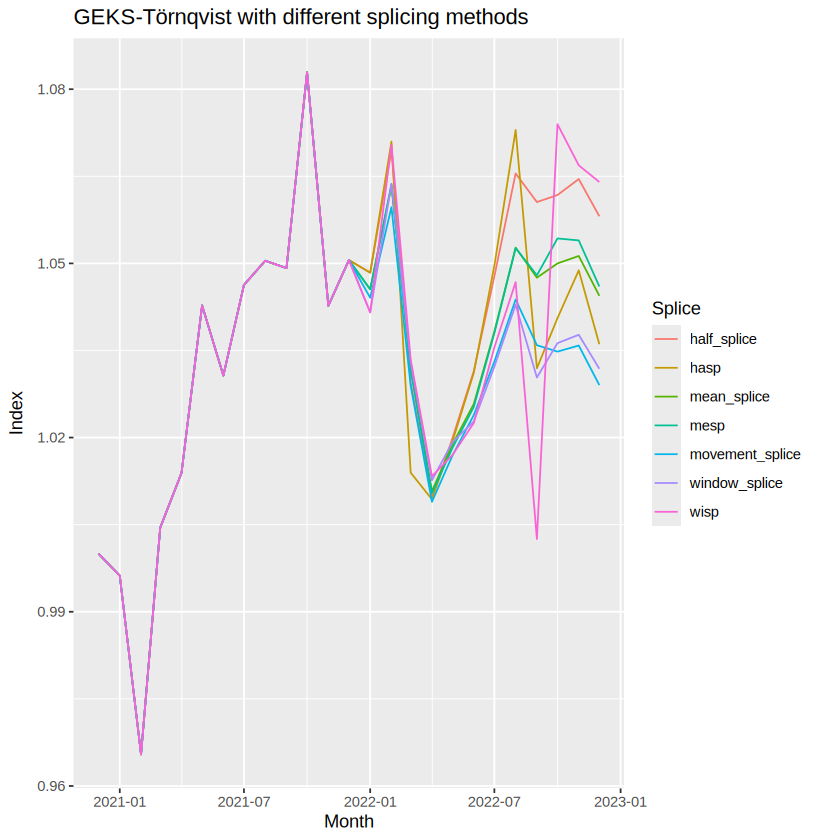

In [27]:
# Combine all splicing methods in a data frame
splices <- data.frame(
  Month = start + months(seq(per_nbr)- 1),
  movement_splice = movement_splice,
  window_splice = window_splice,
  wisp = wisp,
  half_splice = half_splice,
  hasp = hasp,
  mean_splice = mean_splice,
  mesp = mesp
)

# Visualisation of the indices
pivot_longer(splices, cols = -Month, names_to = "Splice", values_to = "Index") %>%
 ggplot(., aes(x = Month, y = Index, group = Splice, color = Splice)) +
 geom_line() +
 ggtitle("GEKS-Törnqvist with different splicing methods")